Task 3 : Predicting Insurance Claim Amounts
Objective:
Predict medical insurance charges using Linear Regression based on personal data. To analyze key factors and evaluate model accuracy using MAE and RMSE.

Import Libraries

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


In [8]:
df = pd.read_csv(r'C:\Users\saad\Desktop\insurance.csv')   # Import Dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.describe()   #Check Statistic Summery of Dataset

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.shape   #Check columns and rows in dataset

(1338, 7)

In [12]:
df.isnull().sum()    #Check Null Values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
df[df.duplicated(keep=False)]  # Checking Duplicate rows

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [14]:
df = df.drop_duplicates()   #Remove Duplicate rows

From the above Data Analysis our Data ic completely Clean there is no missing or duplicate format issue data is ready for Visualization

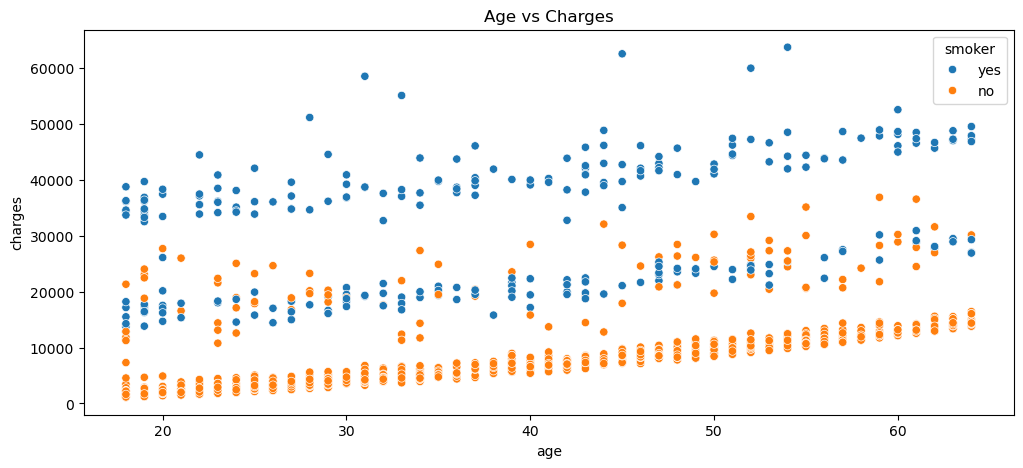

In [15]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='age', y='charges' , data= df , hue='smoker')
plt.title("Age vs Charges")
plt.show()

The graph shows a positive relationship between age and Insurance like the individuals with higher age tend to spend more on insurance charges compared to younger individuals. It also indicates that smokers generally pay significantly higher insurance charges than non-smokers.

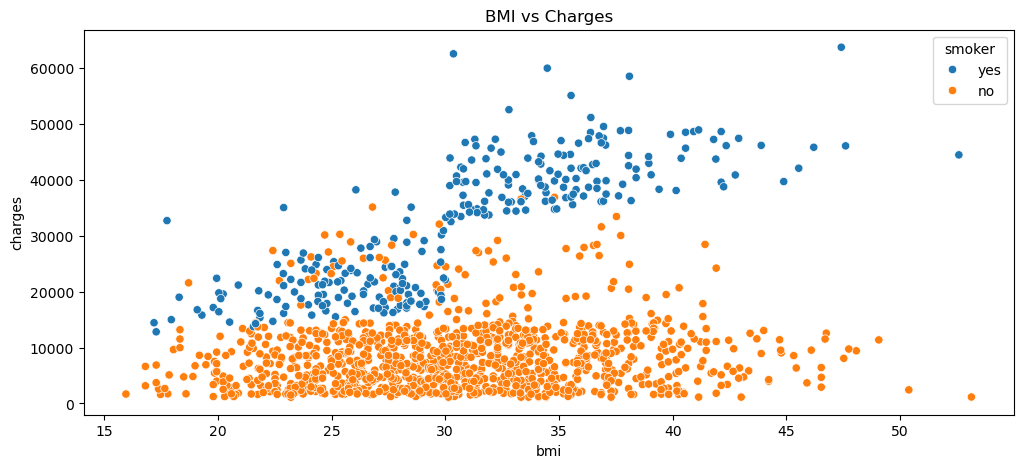

In [16]:
plt.figure(figsize=(12,5))
sns.scatterplot(x='bmi',y='charges', data= df, hue='smoker')
plt.title("BMI vs Charges")
plt.show()

The graph shows that smokers with a BMI ranging from 20 to 45 tend to spend significantly more on insurance charges compared to non-smokers within the same BMI range. This indicates that smoking has a strong impact on increasing insurance costs.

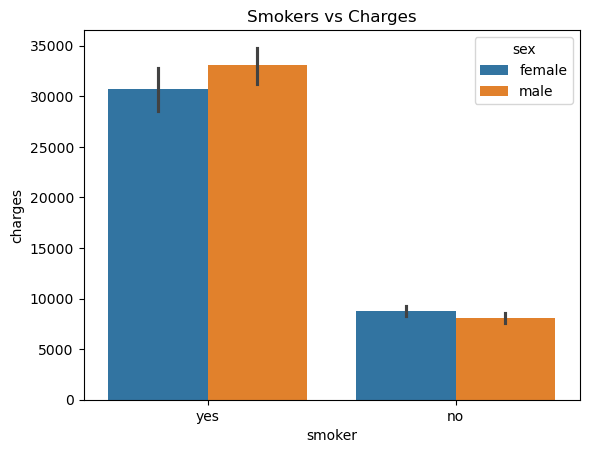

In [17]:
sns.barplot(x='smoker', y='charges',data=df, hue='sex')
plt.title("Smokers vs Charges")
plt.show()

Here we can Analysis that Smoker spend more then non-smoker persons also in Smoker male smoker spend more compare to Female Smokers



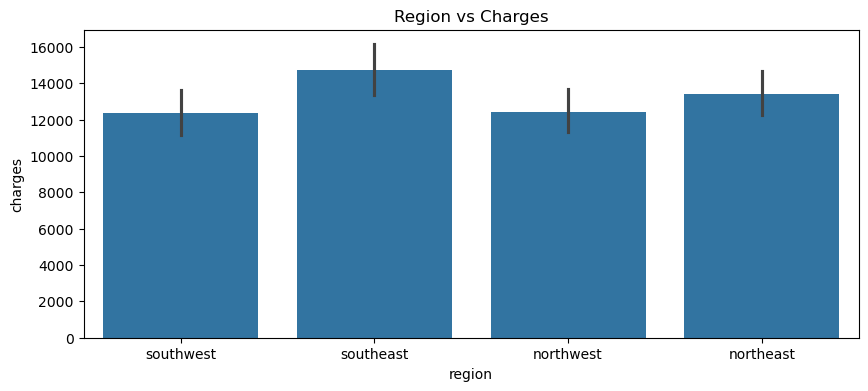

In [18]:
plt.figure(figsize=(10,4))
sns.barplot(x='region', y='charges',data=df)
plt.title("Region vs Charges")
plt.show()

Here we can clearly see all the charges regions wise and top of the region is Southeast spend more then other regions

Encode the Variable for conversion in Binary for Machine Learning

In [19]:
le = LabelEncoder()    #Create Object of LabelEcnoder

for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

In [20]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


In [21]:
X = df.drop('charges', axis=1)  

In [22]:
y = df['charges']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
model = LinearRegression()

In [25]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
print(model.coef_)
print(model.intercept_)

[  248.76407134   -99.69539417   312.60904469   534.12087654
 23052.15275173  -237.62514748]
-11047.686556720197


model.coef_ shows the weight (impact) of each input feature on predicting insurance charges, indicating how much the output changes when a feature increases by one unit. model.intercept_ is the base value of the model, representing the starting predicted charge when all input features are zero.

In [27]:
y_pred = model.predict(X_test)

In [28]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(10))

           Actual     Predicted
900    8688.85885   8080.450186
1064   5708.86700   5592.871120
1256  11436.73815  14378.298655
298   38746.35510  31731.819541
237    4463.20510   9158.356944
481    9304.70190  13361.014269
240   38511.62830  30257.655258
277    2150.46900   1308.647356
415    7345.72660  10849.425445
707   10264.44210  11375.548519


In [29]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4182.353155288299


The Mean Absolute Error (MAE) measures the average difference between the actual and predicted insurance charges made by the Linear Regression model. A lower MAE value indicates that the model is making more accurate predictions with smaller prediction errors.

In [30]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 5957.608799816462


In [31]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8068466322629111


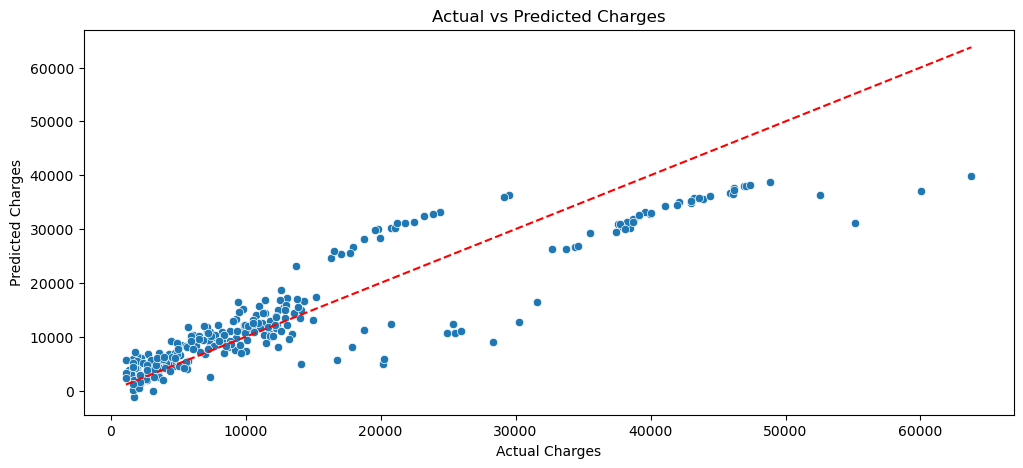

In [32]:
plt.figure(figsize=(12,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

The graph compares actual insurance charges with predicted values generated by the Linear Regression model. Most points are closely aligned along the diagonal line, indicating that the model performs reasonably well in predicting insurance charges. However, some deviations suggest minor prediction errors.

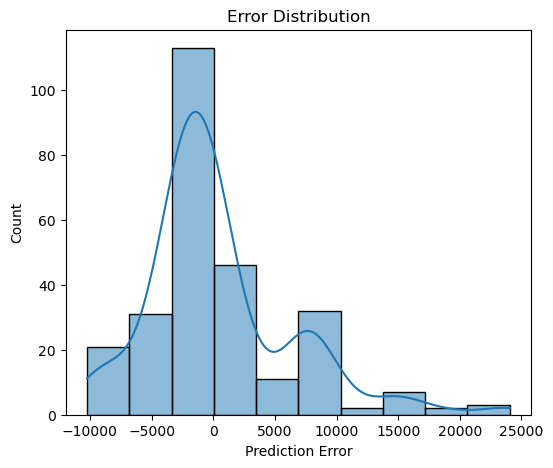

In [39]:

residuals = y_test - y_pred

plt.figure(figsize=(6,5))

sns.histplot( residuals , bins=10, kde=True)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")

plt.show()


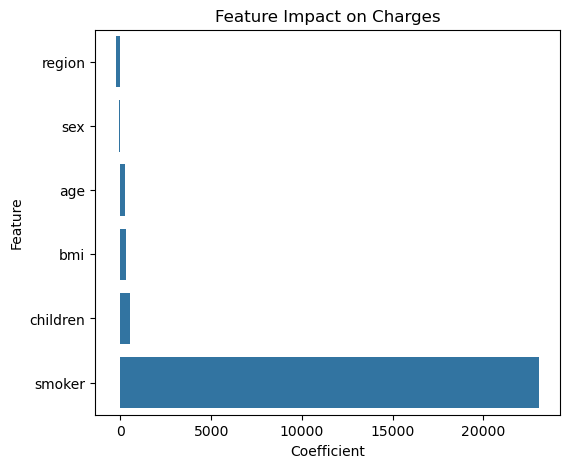

In [35]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient")
plt.figure(figsize=(6,5))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Feature Impact on Charges")
plt.show()

Conclusion
We Conclued that smoking status is the most dominant factor in increasing medical insurance charges, followed by BMI and age. Smokers consistently have significantly higher insurance costs compared to non-smokers, while higher BMI and older age also lead to increased charges.

The model was able to capture these patterns and make reasonably accurate predictions, showing that personal lifestyle factors have a strong impact on insurance pricing.